# K-nearest neighbors for classification

K-nearest neighbors (KNN) is a simple algorithm that *stores* all available cases and classifies new cases based on a similarity measure (e.g., distance functions). It is mostly used for classification problems. In this notebook, we will use a KNN implementation from the `sklearn` library to classify the famous Iris dataset and the MNIST dataset.

**Aprendizado Profundo para Reconhecimento Visual** — Ifes Campus Serra
Autor: Thiago M. Paixão

In [19]:
# If True, test is running on Colab. Otherwise, test if assumed to be offline.
TEST_ON_COLAB = True
FOLDERNAME = 'Colab Notebooks/Aprendizado Profundo para Reconhecimento Visual/02_image-classification'

assert not (FOLDERNAME is None and TEST_ON_COLAB), "FOLDERNAME has to be set if TEST_ON_COLAB is True"

In [20]:
# Create dataset directory
import os

if TEST_ON_COLAB:
    # This mounts your Google Drive to the Colab VM.
    from google.colab import drive

    drive.mount('/content/drive')
    os.chdir(f'/content/drive/My Drive/{FOLDERNAME}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Iris dataset description
from https://openml.org/search?type=data&status=active&id=61

**Author:** R.A. Fisher  
**Source:** UCI - 1936 - Donated by Michael Marshall

**Iris Plants Database**

This is perhaps the best known database to be found in the pattern recognition literature. Fisher's paper is a classic in the field and is referenced frequently to this day. (See Duda & Hart, for example.) The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other.

**Predicted attribute:** class of iris plant.  
This is an exceedingly simple domain.

### Attribute Information:
1. Sepal length in cm
2. Sepal width in cm
3. Petal length in cm
4. Petal width in cm
5. Class:
    - Iris Setosa
    - Iris Versicolour
    - Iris Virginica

In [21]:
# Set the dataset OpenML ID ################
DATASET_OPENML_ID = "iris"
############################################

assert DATASET_OPENML_ID is not None, "DATASET_OPENML_ID is not set"

In [22]:
# Define the directory and file paths for saving the dataset
cache_dir = f"dataset/{DATASET_OPENML_ID}"
os.makedirs(cache_dir, exist_ok=True)

# Fetching the dataset
from sklearn.datasets import fetch_openml
import numpy as np

X_file_path = f"{cache_dir}/X.npy"
y_file_path = f"{cache_dir}/y.npy"

# Check if the dataset files already exist
if not (os.path.exists(X_file_path) and os.path.exists(y_file_path)):
    # Fetch the dataset where X is the data and y is the target
    X, y = fetch_openml(DATASET_OPENML_ID, as_frame=False, cache=True, return_X_y=True)

    # Save the dataset as numpy arrays
    np.save(X_file_path, X.astype(np.float32))
    np.save(y_file_path, y)
    print(f"{DATASET_OPENML_ID} dataset downloaded and saved successfully to {cache_dir}.")
else:
    X = np.load(X_file_path, allow_pickle=True)
    y = np.load(y_file_path, allow_pickle=True)
    print(f"{DATASET_OPENML_ID} dataset already exists in {cache_dir}. Skipping download.")

iris dataset already exists in dataset/iris. Skipping download.


In [23]:
print("5 first samples")
print(X[:5])
print(y[:5])

print("Shape of the dataset", X.shape)
print("Min", X.min())
print("Max", X.max())

5 first samples
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
Shape of the dataset (150, 4)
Min 0.1
Max 7.9


### Splitting data intro training, validation, and test sets.

In [24]:
from sklearn.model_selection import train_test_split

# Set the random seed for reproducibility
np.random.seed(42)

# Convert labels from string to integer
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the dataset into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

In [25]:
print("Flower types:", label_encoder.classes_)
print("Label mapping:", {index: label for index, label in enumerate(label_encoder.classes_)})

Flower types: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Label mapping: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}


In [26]:
print("Dataset split:")
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Dataset split:
Train: (105, 4) (105,)
Test: (45, 4) (45,)


In [27]:
print("5 first train samples")
print(X_train[:5])
print(y_train[:5])

print("\n5 first test samples")
print(X_test[:5])
print(y_test[:5])

5 first train samples
[[5.5 2.4 3.7 1. ]
 [6.3 2.8 5.1 1.5]
 [6.4 3.1 5.5 1.8]
 [6.6 3.  4.4 1.4]
 [7.2 3.6 6.1 2.5]]
[1 2 2 1 2]

5 first test samples
[[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]]
[1 0 2 1 1]


### KNN classifier

Doc: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [28]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=3)

# Memoryze the samples
neigh.fit(X_train, y_train)

# Predict the labels
y_pred = neigh.predict(X_test)

In [29]:
print("Predictions:", y_pred)
print("True labels:", y_test)

accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
Accuracy: 1.0


### MNIST dataset description
from https://openml.org/search?type=data&status=active&id=554

Author: Yann LeCun, Corinna Cortes, Christopher J.C. Burges
Source: MNIST Website - Date unknown
Please cite:

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image by computing the center of mass of the pixels, and translating the image so as to position this point at the center of the 28x28 field.

With some classification methods (particularly template-based methods, such as SVM and K-nearest neighbors), the error rate improves when the digits are centered by bounding box rather than center of mass. If you do this kind of pre-processing, you should report it in your publications. The MNIST database was constructed from NIST's NIST originally designated SD-3 as their training set and SD-1 as their test set. However, SD-3 is much cleaner and easier to recognize than SD-1. The reason for this can be found on the fact that SD-3 was collected among Census Bureau employees, while SD-1 was collected among high-school students. Drawing sensible conclusions from learning experiments requires that the result be independent of the choice of training set and test among the complete set of samples. Therefore it was necessary to build a new database by mixing NIST's datasets.

The MNIST training set is composed of 30,000 patterns from SD-3 and 30,000 patterns from SD-1. Our test set was composed of 5,000 patterns from SD-3 and 5,000 patterns from SD-1. The 60,000 pattern training set contained examples from approximately 250 writers. We made sure that the sets of writers of the training set and test set were disjoint. SD-1 contains 58,527 digit images written by 500 different writers. In contrast to SD-3, where blocks of data from each writer appeared in sequence, the data in SD-1 is scrambled. Writer identities for SD-1 is available and we used this information to unscramble the writers. We then split SD-1 in two: characters written by the first 250 writers went into our new training set. The remaining 250 writers were placed in our test set. Thus we had two sets with nearly 30,000 examples each. The new training set was completed with enough examples from SD-3, starting at pattern # 0, to make a full set of 60,000 training patterns. Similarly, the new test set was completed with SD-3 examples starting at pattern # 35,000 to make a full set with 60,000 test patterns. Only a subset of 10,000 test images (5,000 from SD-1 and 5,000 from SD-3) is available on this site. The full 60,000 sample training set is available.

In [30]:
# TODO: Set the dataset ID #################
DATASET_OPENML_ID = "mnist_784"
############################################

assert DATASET_OPENML_ID is not None, "DATASET_OPENML_ID is not set"

In [31]:
# Define the directory and file paths for saving the dataset
cache_dir = f"dataset/{DATASET_OPENML_ID}"
os.makedirs(cache_dir, exist_ok=True)

# Fetching the dataset
from sklearn.datasets import fetch_openml
import numpy as np

X_file_path = f"{cache_dir}/X.npy"
y_file_path = f"{cache_dir}/y.npy"

# Check if the dataset files already exist
if not (os.path.exists(X_file_path) and os.path.exists(y_file_path)):
    # Fetch the dataset where X is the data and y is the target
    X, y = fetch_openml(DATASET_OPENML_ID, as_frame=False, cache=True, return_X_y=True)

    # Save the dataset as numpy arrays
    np.save(X_file_path, X.astype(np.float32))
    np.save(y_file_path, y)
    print(f"{DATASET_OPENML_ID} dataset downloaded and saved successfully to {cache_dir}.")
else:
    X = np.load(X_file_path, allow_pickle=True)
    y = np.load(y_file_path, allow_pickle=True)
    print(f"{DATASET_OPENML_ID} dataset already exists in {cache_dir}. Skipping download.")

mnist_784 dataset already exists in dataset/mnist_784. Skipping download.


In [32]:
print("5 first samples")
print(X[:5])
print(y[:5])

print("Shape of the dataset", X.shape)
print("Min", X.min())
print("Max", X.max())

5 first samples
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
['5' '0' '4' '1' '9']
Shape of the dataset (70000, 784)
Min 0.0
Max 255.0


### Plot samples from the dataset

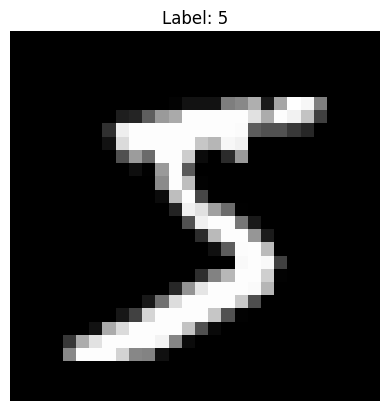

In [33]:
image = X[0].reshape(28, 28)
label = y[0]

import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

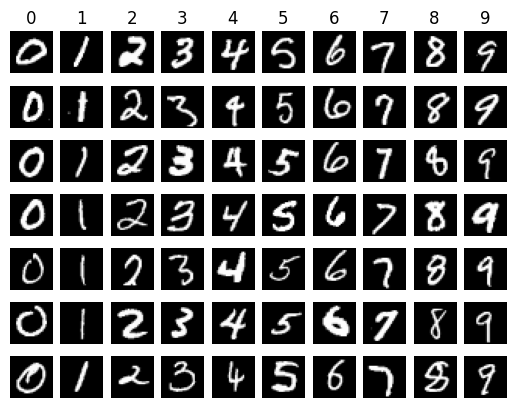

In [34]:
num_classes = 10

# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = [int(class_id) for class_id in np.unique(y)]
samples_per_class = 7
for cls in classes:
    idxs = np.flatnonzero(y == str(cls))
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + cls + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X[idx].reshape((28, -1)).astype('uint8'), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

### Splitting data intro training, validation, and test sets.

In [42]:
from sklearn.model_selection import train_test_split

# Set the random seed for reproducibility
np.random.seed(42)

# Convert labels from string to integer
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Alternative approach...
# y = y.astype(np.int32)

# Split the dataset into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [36]:
print("Classes:", label_encoder.classes_)
print("Label mapping:", {index: label for index, label in enumerate(label_encoder.classes_)})

Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Label mapping: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [37]:
print("Dataset split:")
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Dataset split:
Train: (56000, 784) (56000,)
Test: (14000, 784) (14000,)


In [38]:
print("5 first train samples")
print(X_train[:5])
print(y_train[:5])

print("\n5 first test samples")
print(X_test[:5])
print(y_test[:5])

5 first train samples
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[5 4 8 0 2]

5 first test samples
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[8 4 8 7 7]


### KNN classifier

In [39]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=3)

# Memoryze the samples
neigh.fit(X_train, y_train)

# Predict the labels
y_pred = neigh.predict(X_test)

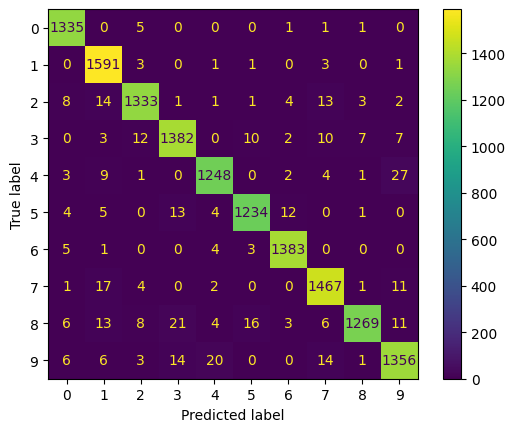


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1343
           1       0.96      0.99      0.98      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.96      0.97      1433
           4       0.97      0.96      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.98      0.97      1503
           8       0.99      0.94      0.96      1357
           9       0.96      0.95      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [40]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[class_id for class_id in range(10)])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_id for class_id in range(10)])
disp.plot()
plt.show()

# Compute classification report
class_report = classification_report(y_test, y_pred, target_names=[str(class_id) for class_id in range(10)])

print("\nClassification Report:")
print(class_report)

In [41]:
print("Predictions:", y_pred)
print("True labels:", y_test)

accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Predictions: [8 4 8 ... 2 7 1]
True labels: [8 4 8 ... 2 7 1]
Accuracy: 0.9712857142857143
